In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

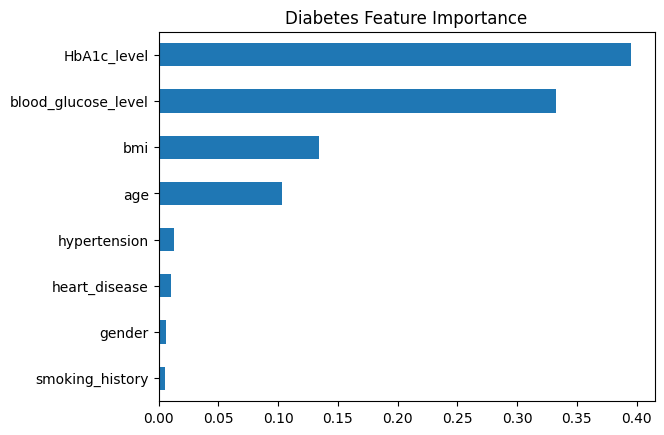

In [2]:

# DIABETES 

df = pd.read_csv("../data/diabetes.csv")

# Encoding
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['smoking_history'] = df['smoking_history'].map({
    'never': 0, 'No Info': 0,
    'current': 1, 'former': 1,
    'ever': 1, 'not current': 1
})

df.dropna(inplace=True)

X = df.drop('diabetes', axis=1)
y = df['diabetes']

rf = RandomForestClassifier()
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

importance.plot(kind='barh')
plt.title("Diabetes Feature Importance")
plt.show()

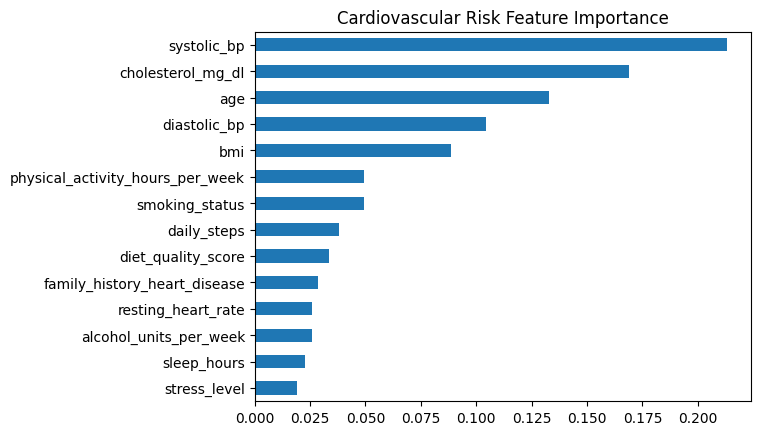

In [3]:
# HEART (Cardiovascular Dataset)

df = pd.read_csv("../data/cardiovascular.csv")

# Encode categorical columns used as features
df_encoded = df.copy()

smoking_map = {"Never": 0, "Former": 1, "Current": 2}
family_history_map = {"No": 0, "Yes": 1}
risk_map = {"Low": 0, "Medium": 1, "High": 2}

df_encoded["smoking_status"] = df_encoded["smoking_status"].map(smoking_map)
df_encoded["family_history_heart_disease"] = df_encoded["family_history_heart_disease"].map(family_history_map)
df_encoded["risk_category"] = df_encoded["risk_category"].map(risk_map)

df_encoded.dropna(inplace=True)

# Target and features
target_col = "risk_category"

# Exclude identifier and continuous risk score from feature-importance model
X = df_encoded.drop(columns=["Patient_ID", "heart_disease_risk_score", target_col])
y = df_encoded[target_col]

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

# Plot
importance.plot(kind='barh')
plt.title("Cardiovascular Risk Feature Importance")
plt.show()


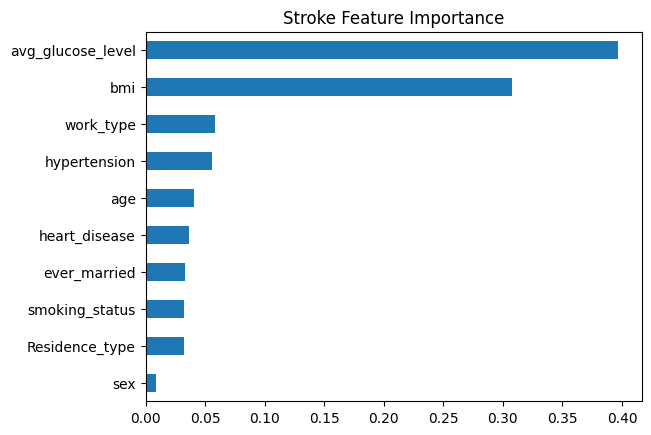

In [4]:

# STROKE


df = pd.read_csv("../data/stroke_data.csv")

# Auto encode
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

df_encoded.dropna(inplace=True)

# Detect target
if 'stroke' in df_encoded.columns:
    target_col = 'stroke'
else:
    raise ValueError("Target column not found")

X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

rf = RandomForestClassifier()
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

importance.plot(kind='barh')
plt.title("Stroke Feature Importance")
plt.show()